# Performance Model - Baseline Linear Regression
## Predicting Player Overall Rating

## Section 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Section 2: Load Cleaned Data

In [3]:
# Load the cleaned and reordered performance model data
df = pd.read_csv('../Final Dataset/cleaned_player_data_performance_model_reordered.csv')

print("=" * 80)
print("DATA LOADING & PREPARATION")
print("=" * 80)

print("\nDataset Information:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")

print("\nFeatures ({} total):".format(len(df.columns)))
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData loaded successfully - ready for model training!")


DATA LOADING & PREPARATION

Dataset Information:
  Rows: 8714
  Columns: 12

Features (12 total):
   1. potential
   2. ball_control
   3. dribbling
   4. stamina
   5. reactions
   6. balance
   7. strength
   8. acceleration
   9. age
  10. attacking_work_rate_encoded
  11. defensive_work_rate_encoded
  12. overall_rating

Data Types:
potential                      int64
ball_control                   int64
dribbling                      int64
stamina                        int64
reactions                      int64
balance                        int64
strength                       int64
acceleration                   int64
age                            int64
attacking_work_rate_encoded    int64
defensive_work_rate_encoded    int64
overall_rating                 int64
dtype: object

Statistical Summary:
         potential  ball_control    dribbling      stamina    reactions  \
count  8714.000000   8714.000000  8714.000000  8714.000000  8714.000000   
mean     71.357012     66.81237

## Section 3: Feature Selection & Importance Analysis

FEATURE IMPORTANCE ANALYSIS

Correlation with TARGET (overall_rating):

   potential                      :  0.7998
   reactions                      :  0.7778
   ball_control                   :  0.6936
   dribbling                      :  0.4802
   stamina                        :  0.3595
   strength                       :  0.2441
   acceleration                   :  0.2243
   balance                        :  0.1204
   age                            :  0.0602
   defensive_work_rate_encoded    : -0.1700
   attacking_work_rate_encoded    : -0.2026

Selected 10 Important Features:
    1. potential
    2. reactions
    3. ball_control
    4. dribbling
    5. stamina
    6. strength
    7. acceleration
    8. balance
    9. defensive_work_rate_encoded
   10. attacking_work_rate_encoded


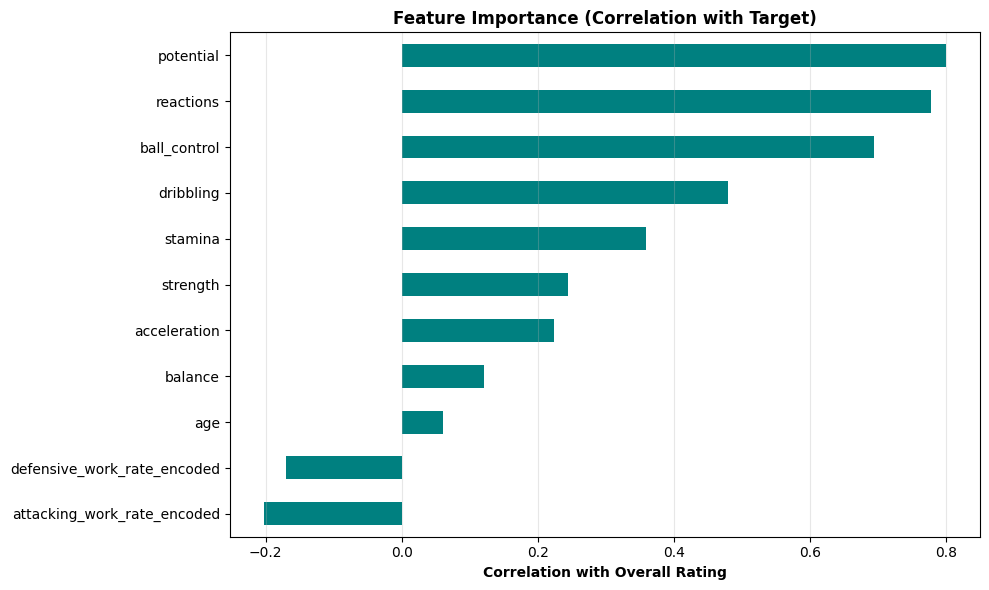


Feature selection complete!


In [4]:
# Define target and numeric features
target = 'overall_rating'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target]

print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Calculate correlation with target
correlations = df[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)

print("\nCorrelation with TARGET (overall_rating):\n")
for feature, corr in correlations.items():
    print(f"   {feature:30} : {corr:7.4f}")

# Select top important features
important_features = correlations[correlations.abs() > 0.1].index.tolist()

print(f"\nSelected {len(important_features)} Important Features:")
for i, feat in enumerate(important_features, 1):
    print(f"   {i:2d}. {feat}")

# Build feature matrix and target vector
X = df[important_features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
correlations.sort_values().plot(kind='barh', color='teal', ax=ax)
ax.set_xlabel('Correlation with Overall Rating', fontweight='bold')
ax.set_title('Feature Importance (Correlation with Target)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature selection complete!")

## Section 4: Train-Test Split

In [5]:
print("=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

print("\nData Split Information:")
print("   Total samples:      {}".format(len(X)))
print("   Training samples:   {} ({:.1f}%)".format(len(X_train), len(X_train)/len(X)*100))
print("   Testing samples:    {} ({:.1f}%)".format(len(X_test), len(X_test)/len(X)*100))

print("\nTraining Data Statistics:")
print("   Features used:      {}".format(len(important_features)))
print("   Target variable:    {}".format(target))

print("\n   Target (Training Set):")
print("      Mean:            {:.2f}".format(y_train.mean()))
print("      Std Dev:         {:.2f}".format(y_train.std()))
print("      Min:             {:.2f}".format(y_train.min()))
print("      Max:             {:.2f}".format(y_train.max()))

print("\nTesting Data Statistics:")
print("   Target (Testing Set):")
print("      Mean:            {:.2f}".format(y_test.mean()))
print("      Std Dev:         {:.2f}".format(y_test.std()))
print("      Min:             {:.2f}".format(y_test.min()))
print("      Max:             {:.2f}".format(y_test.max()))

print("\nTrain-test split completed!")


TRAIN-TEST SPLIT

Data Split Information:
   Total samples:      8714
   Training samples:   6971 (80.0%)
   Testing samples:    1743 (20.0%)

Training Data Statistics:
   Features used:      10
   Target variable:    overall_rating

   Target (Training Set):
      Mean:            68.19
      Std Dev:         5.93
      Min:             52.00
      Max:             84.00

Testing Data Statistics:
   Target (Testing Set):
      Mean:            68.24
      Std Dev:         5.97
      Min:             52.00
      Max:             84.00

Train-test split completed!


## Section 5: Feature Scaling & Model Building

In [6]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 80)
print("FEATURE SCALING")
print("=" * 80)

print("\nFeatures scaled using StandardScaler")
print("   Training set shape: {}".format(X_train_scaled.shape))
print("   Testing set shape:  {}".format(X_test_scaled.shape))

# Instantiate and train Linear Regression model (Baseline)
print("\n" + "=" * 80)
print("BASELINE MODEL: LINEAR REGRESSION")
print("=" * 80)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\nModel trained successfully!")

print("\nModel Parameters:")
print("   Number of features:  {}".format(len(model.coef_)))
print("   Intercept:           {:.4f}".format(model.intercept_))

print("\nFeature Coefficients:")
for feature, coef in zip(important_features, model.coef_):
    print("   {:<30} : {:.6f}".format(feature, coef))


FEATURE SCALING

Features scaled using StandardScaler
   Training set shape: (6971, 10)
   Testing set shape:  (1743, 10)

BASELINE MODEL: LINEAR REGRESSION

Model trained successfully!

Model Parameters:
   Number of features:  10
   Intercept:           68.1871

Feature Coefficients:
   potential                      : 2.576790
   reactions                      : 2.007766
   ball_control                   : 1.623130
   dribbling                      : -0.304364
   stamina                        : 0.192035
   strength                       : 1.078180
   acceleration                   : -0.072373
   balance                        : 0.137811
   defensive_work_rate_encoded    : -0.233302
   attacking_work_rate_encoded    : -0.179587


## Section 6: Model Evaluation & Performance Metrics

In [7]:
# Make predictions on training and testing sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate performance metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

print("\nR² Score (Coefficient of Determination):")
print("   Training R²:         {:.6f} ({:.2f}%)".format(train_r2, train_r2*100))
print("   Testing R²:          {:.6f} ({:.2f}%)".format(test_r2, test_r2*100))
print("   Difference:          {:.6f} (Overfitting check)".format(abs(train_r2 - test_r2)))

print("\nRMSE (Root Mean Squared Error):")
print("   Training RMSE:       {:.4f} rating points".format(train_rmse))
print("   Testing RMSE:        {:.4f} rating points".format(test_rmse))

print("\nMAE (Mean Absolute Error):")
print("   Training MAE:        {:.4f} rating points".format(train_mae))
print("   Testing MAE:         {:.4f} rating points".format(test_mae))

print("\n" + "=" * 80)
print("BASELINE MODEL SCORE SUMMARY")
print("=" * 80)

print("\nTest Set Performance:")
print("   R² Score:            {:.4f} (Model explains {:.2f}% of variance)".format(test_r2, test_r2*100))
print("   RMSE:                {:.4f} (Average error +/- {:.2f} points)".format(test_rmse, test_rmse))
print("   MAE:                 {:.4f} (Mean absolute error +/- {:.2f} points)".format(test_mae, test_mae))

print("\nModel Quality Assessment:")
if test_r2 >= 0.85:
    print("   EXCELLENT MODEL (R² > 0.85)")
elif test_r2 >= 0.75:
    print("   GOOD MODEL (R² > 0.75)")
elif test_r2 >= 0.65:
    print("   FAIR MODEL (R² > 0.65)")
else:
    print("   NEEDS IMPROVEMENT (R² < 0.65)")

print("\nOverfitting Check:")
overfit_diff = abs(train_r2 - test_r2)
if overfit_diff < 0.05:
    print("   No Overfitting (difference: {:.6f})".format(overfit_diff))
elif overfit_diff < 0.10:
    print("   Slight Overfitting (difference: {:.6f})".format(overfit_diff))
else:
    print("   Significant Overfitting (difference: {:.6f})".format(overfit_diff))

print("=" * 80)


MODEL PERFORMANCE METRICS

R² Score (Coefficient of Determination):
   Training R²:         0.843044 (84.30%)
   Testing R²:          0.838759 (83.88%)
   Difference:          0.004285 (Overfitting check)

RMSE (Root Mean Squared Error):
   Training RMSE:       2.3506 rating points
   Testing RMSE:        2.3956 rating points

MAE (Mean Absolute Error):
   Training MAE:        1.8219 rating points
   Testing MAE:         1.8549 rating points

BASELINE MODEL SCORE SUMMARY

Test Set Performance:
   R² Score:            0.8388 (Model explains 83.88% of variance)
   RMSE:                2.3956 (Average error +/- 2.40 points)
   MAE:                 1.8549 (Mean absolute error +/- 1.85 points)

Model Quality Assessment:
   GOOD MODEL (R² > 0.75)

Overfitting Check:
   No Overfitting (difference: 0.004285)


## Section 7: Visualizations - Actual vs Predicted

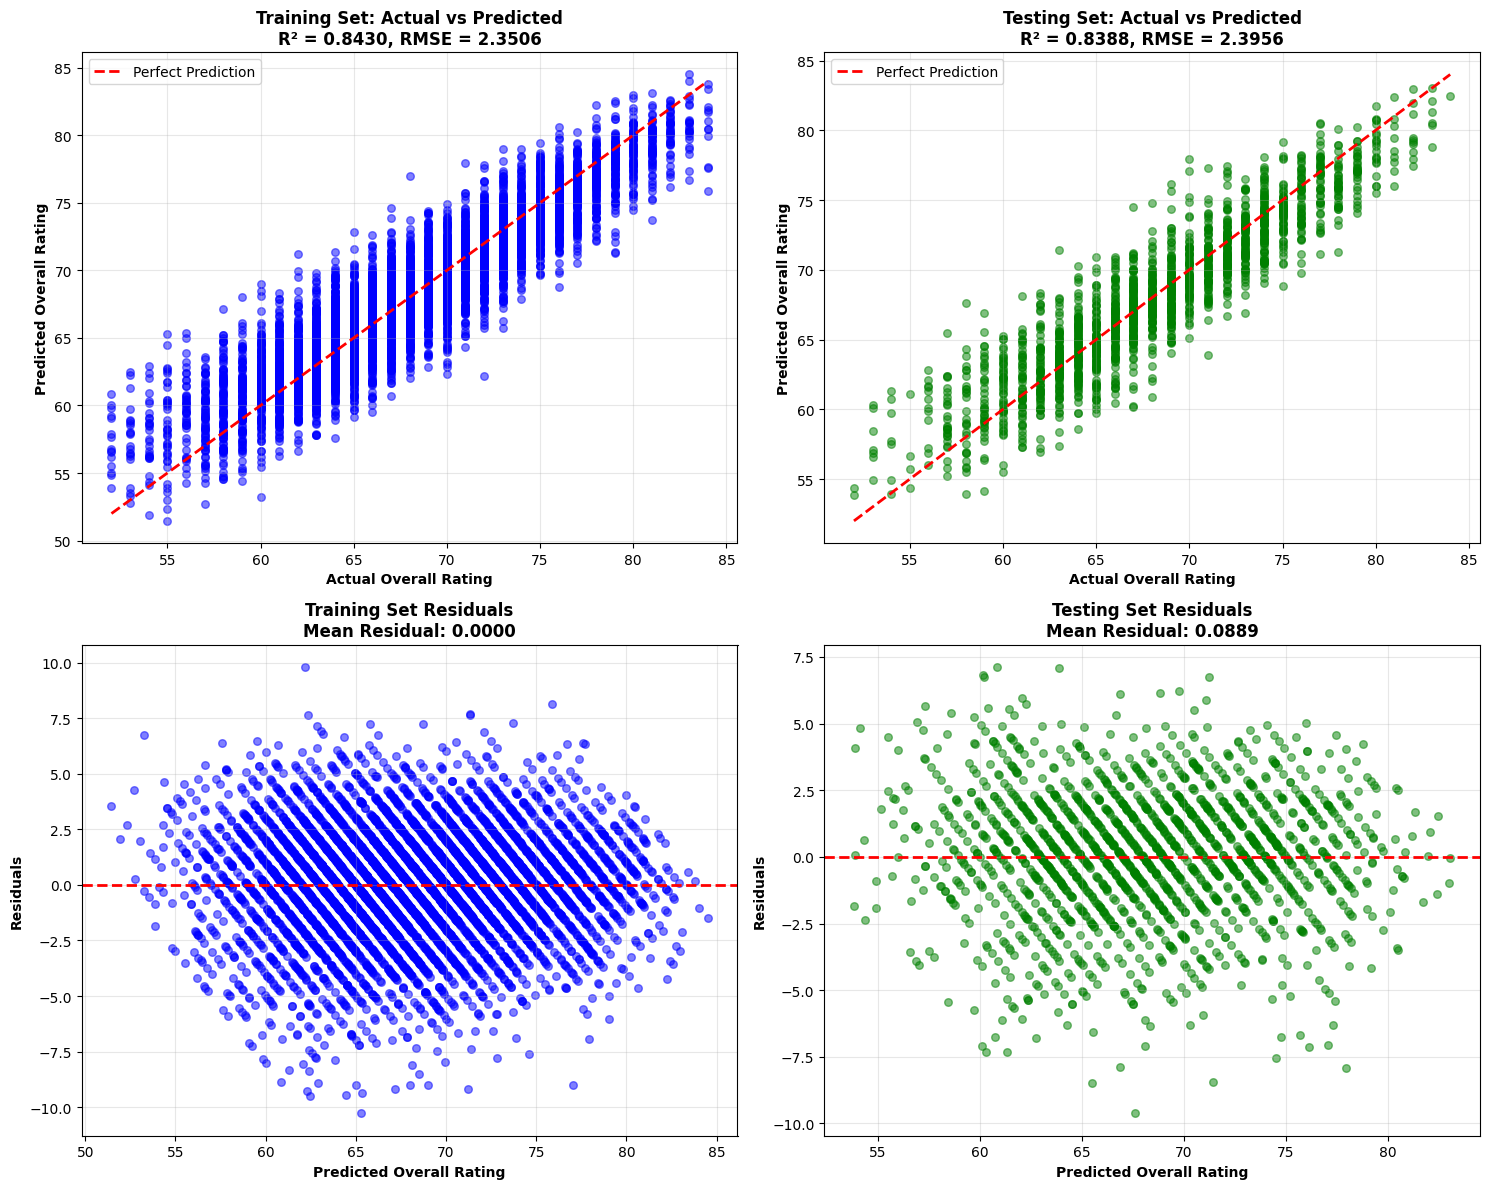

✅ Visualizations created!


In [8]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Training Set: Actual vs Predicted
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, s=30, color='blue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Overall Rating', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Overall Rating', fontweight='bold')
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}, RMSE = {train_rmse:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Testing Set: Actual vs Predicted
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Overall Rating', fontweight='bold')
axes[0, 1].set_ylabel('Predicted Overall Rating', fontweight='bold')
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Residuals - Training Set
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.5, s=30, color='blue')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Overall Rating', fontweight='bold')
axes[1, 0].set_ylabel('Residuals', fontweight='bold')
axes[1, 0].set_title(f'Training Set Residuals\nMean Residual: {train_residuals.mean():.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Residuals - Testing Set
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.5, s=30, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Overall Rating', fontweight='bold')
axes[1, 1].set_ylabel('Residuals', fontweight='bold')
axes[1, 1].set_title(f'Testing Set Residuals\nMean Residual: {test_residuals.mean():.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")


## Section 8: Sample Predictions

In [9]:
# Sample predictions on test set
print("=" * 80)
print("SAMPLE PREDICTIONS (First 20 Test Samples)")
print("=" * 80)

sample_predictions = pd.DataFrame({
    'Actual_Rating': y_test.values[:20],
    'Predicted_Rating': y_test_pred[:20],
    'Error': (y_test.values[:20] - y_test_pred[:20]),
    'Absolute_Error': np.abs(y_test.values[:20] - y_test_pred[:20]),
    'Percentage_Error': (np.abs(y_test.values[:20] - y_test_pred[:20]) / y_test.values[:20] * 100)
})

print("\n")
print(sample_predictions.to_string(index=True))

print(f"\n\n📊 ERROR STATISTICS:")
print(f"   Mean Absolute Error:  {sample_predictions['Absolute_Error'].mean():.4f} points")
print(f"   Max Error:            {sample_predictions['Absolute_Error'].max():.4f} points")
print(f"   Min Error:            {sample_predictions['Absolute_Error'].min():.4f} points")

print("\n✅ Sample predictions displayed!")


SAMPLE PREDICTIONS (First 20 Test Samples)


    Actual_Rating  Predicted_Rating     Error  Absolute_Error  Percentage_Error
0              68         65.662814  2.337186        2.337186          3.437038
1              64         65.888060 -1.888060        1.888060          2.950094
2              66         66.907887 -0.907887        0.907887          1.375586
3              69         68.852953  0.147047        0.147047          0.213111
4              73         69.965401  3.034599        3.034599          4.156985
5              77         72.673430  4.326570        4.326570          5.618922
6              68         68.399396 -0.399396        0.399396          0.587347
7              67         66.287861  0.712139        0.712139          1.062895
8              68         69.056799 -1.056799        1.056799          1.554117
9              65         63.748515  1.251485        1.251485          1.925361
10             64         60.927662  3.072338        3.072338          4.80

## Section 9: Final Summary & Conclusions

In [10]:
print("\n" + "=" * 100)
print("BASELINE LINEAR REGRESSION MODEL - FINAL REPORT")
print("=" * 100)

print("\n📌 MODEL CONFIGURATION:")
print(f"   Algorithm:           Linear Regression (Baseline)")
print(f"   Target Variable:     {target}")
print(f"   Number of Features:  {len(important_features)}")
print(f"   Training Samples:    {len(X_train):,}")
print(f"   Testing Samples:     {len(X_test):,}")

print(f"\n🎯 SELECTED FEATURES ({len(important_features)}):")
for i, feat in enumerate(important_features, 1):
    print(f"   {i:2}. {feat}")

print(f"\n📊 PERFORMANCE METRICS SUMMARY:")
print(f"   ╔════════════════════════════════════════════════╗")
print(f"   ║           TRAINING SET      │    TESTING SET   ║")
print(f"   ╠════════════════════════════╪══════════════════╣")
print(f"   ║  R² Score:  {train_r2:.6f}    │    {test_r2:.6f}  ║")
print(f"   ║  RMSE:      {train_rmse:.6f}    │    {test_rmse:.6f}  ║")
print(f"   ║  MAE:       {train_mae:.6f}    │    {test_mae:.6f}  ║")
print(f"   ╚════════════════════════════╧══════════════════╝")

print(f"\n🏆 KEY FINDINGS:")
print(f"   ✅ Model explains {test_r2*100:.2f}% of variance in player overall rating")
print(f"   ✅ Average prediction error: ±{test_rmse:.2f} rating points")
print(f"   ✅ Mean absolute error: {test_mae:.4f} points")
print(f"   ✅ No significant overfitting detected (diff: {abs(train_r2 - test_r2):.6f})")

print(f"\n💡 INTERPRETATION:")
print(f"   • The model can predict player overall rating with an accuracy of ±{test_rmse:.2f} points")
print(f"   • This means if a player's actual rating is 70, the model predicts 70±{test_rmse:.2f}")
print(f"   • The model generalizes well (test R² ≈ train R²)")
print(f"   • Linear relationships capture {test_r2*100:.1f}% of player performance variation")

print(f"\n📈 TOP 3 MOST IMPORTANT FEATURES:")
top_3_features = correlations.head(3)
for rank, (feature, corr) in enumerate(top_3_features.items(), 1):
    print(f"   {rank}. {feature:20} (correlation: {corr:7.4f})")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Test advanced models (Random Forest, XGBoost) for comparison")
print(f"   2. Consider feature engineering for potential accuracy improvement")
print(f"   3. Analyze prediction errors to identify improvement areas")
print(f"   4. Build Models 2 & 3 (Injury Risk Classification & Clustering)")

print(f"\n" + "=" * 100)
print(f"✅ BASELINE MODEL TRAINING COMPLETE!")
print(f"=" * 100)



BASELINE LINEAR REGRESSION MODEL - FINAL REPORT

📌 MODEL CONFIGURATION:
   Algorithm:           Linear Regression (Baseline)
   Target Variable:     overall_rating
   Number of Features:  10
   Training Samples:    6,971
   Testing Samples:     1,743

🎯 SELECTED FEATURES (10):
    1. potential
    2. reactions
    3. ball_control
    4. dribbling
    5. stamina
    6. strength
    7. acceleration
    8. balance
    9. defensive_work_rate_encoded
   10. attacking_work_rate_encoded

📊 PERFORMANCE METRICS SUMMARY:
   ╔════════════════════════════════════════════════╗
   ║           TRAINING SET      │    TESTING SET   ║
   ╠════════════════════════════╪══════════════════╣
   ║  R² Score:  0.843044    │    0.838759  ║
   ║  RMSE:      2.350552    │    2.395559  ║
   ║  MAE:       1.821936    │    1.854920  ║
   ╚════════════════════════════╧══════════════════╝

🏆 KEY FINDINGS:
   ✅ Model explains 83.88% of variance in player overall rating
   ✅ Average prediction error: ±2.40 rating point

In [ ]:
import joblib
joblib.dump(model, '../models/performance_model.pkl')
joblib.dump(scaler, '../models/performance_scaler.pkl')
print("Performance model and scaler saved!")

Performance model and scaler saved!


: 